IN this file I tried to fit AR processess however it all has failed miserably

In [ ]:
import jax
from jax import random
from scipy.stats import *
from scipy import stats 
from typing import Union, List, Literal, TypeAlias
import numpy as np
import numpy.typing as npt
import pandas as pd
from functools import wraps, partial
from arch import arch_model
import time
from dataclasses import dataclass
from jax.scipy.optimize import minimize
import matplotlib.pyplot as plt
from math import exp, pi, sqrt
import seaborn as sns
import jax.numpy as jnp

jax.config.update("jax_enable_x64", True) #for better numerical stability 

number = Union[int, float]
number_like = Union[List[number], number]
array_like = Union[List[number], np.ndarray]
distributions: TypeAlias = Literal["chauchy", "chi2", "expon", "exponpow", "gamma", "lognorm", "norm", "powerlaw", "rayleigh",
                            "uniform", "t", "gumbel_r", "f"]  
FloatArray = npt.NDArray[np.float64]
Floats = Union[float, FloatArray]
Int = Union[int, np.int16, np.int32, np.int64, jnp.int64, jnp.int32, jnp.int16]

from Vares import Auxiliary
import Vares

#1. потестить на несколько дней вперёд 
#2. разные распределения

In [3]:
@dataclass
class GBMParams:
    volatility: Floats 
    mean: Floats 

def make_gbm_simulator(
        params: GBMParams,
        T: int, 
        granularity: int = 1000
    ): 
    '''Creates a Geometric Brownian Motion simulator with predetermined parameters. 
    Returns a batch of simulated data. The simulated data is distributed lognormally shifted by -1 term.
    Parameters correspond to ones drown from normal with mean (params.mean - (params.volatility**2) / 2)) and std params.volatility'''
    def simulate(n_paths: int, seed = None):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        time_grid = T * granularity
        dt = 1 / granularity
        norm = rng.normal(size=(n_paths, time_grid))

        #Simulate log returns paths using GBM.
        d_log_S = (
            (params.mean - ((params.volatility**2) / 2)) * dt 
            + params.volatility * norm * np.sqrt(dt)
        )
        d_log_S = np.insert(d_log_S, 0, np.zeros(n_paths), axis=1)

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        cum_returns = np.exp(cum_log_returns) - 1 

        return cum_returns
    return simulate 

def _terminal_returns(simulator: callable, n_paths: int, seed = None): 
    '''Helper method for stripping and returning the last column of the return matrix.'''
    cummulative_returns = simulator(n_paths, seed)
    terminal_returns = cummulative_returns[:, -1] #in case of GBM terminal return will be distributed lognormally
    return terminal_returns

In [4]:
#same as make_gbm_simulator_2 but with array slicing is needed here.
@Auxiliary.timer
def make_gbm_simulator_local_vol(
        params: GBMParams, 
        T: int, 
        granularity: int = 1000 
): 
    '''Same as make_gbm_simulator(), but allows for varying daily volatility of the underlying. A more flexible solution'''
    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')
    
    def simulate(n_paths, seed = None): 
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        n_vol = params.volatility.shape[0]

        dt = 1 / granularity
        time_grid = T * granularity
        norm = rng.normal(size=(n_paths, time_grid))

        #version 2
        # d_log_S = np.zeros((n_paths, ))
        for day in range(0, n_vol): 

            if day == 0: 
                q = (day+1) * granularity
                z_values = norm[:, :q]

                _ = (
                (params.mean - ((params.volatility[day]**2) / 2)) * dt 
                + params.volatility[day] * z_values * np.sqrt(dt)
                )
                d_log_S = np.concatenate((d_log_S, _), axis=1) if day != 0  else _
            if  0 < day < params.volatility.shape[0]:
                q = (day+1) * granularity
                p = day * granularity
                z_values = norm[:, p:q]

                _ = (
                (params.mean - ((params.volatility[day]**2) / 2)) * dt 
                + params.volatility[day] * z_values * np.sqrt(dt)
                )
                d_log_S = np.concatenate((d_log_S, _), axis=1) if day != 0 else _

        p = n_vol * granularity
        _ = (
        (params.mean - ((params.volatility[-1]**2) / 2)) * dt 
        + params.volatility[-1] * norm[:, p:] * np.sqrt(dt)
        )
        d_log_S = np.concatenate((d_log_S, _), axis=1)
        # d_log_S = np.insert(d_log_S, 0, np.zeros(n_paths), axis=1)

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        cum_returns = np.exp(cum_log_returns) - 1 

        return cum_returns
    return simulate


In [5]:
class ProtoPortfolio: 
    def __init__(self, returns, **kwargs): 
        self.returns = returns #(portfolio) returns
        try:
            self.number_of_assets = self.returns.shape[1] 
        except IndexError: 
            self.number_of_assets = 1

        self.kwargs = kwargs.copy()

    def calibrate(self, horizon=1, **kwargs): 
        '''Private method implies variance and mean of returns of assets' returns using GARCH(p, q)
        
        Now it is unable to handle returns across multiple(>1) assets. Also can not handle horizon > 1'''
        am = arch_model(self.returns, vol='Garch', dist='normal', **kwargs)
        result = am.fit(disp='off')
        forecast = result.forecast(horizon=horizon)
        mu = result.params.get("mu", 0)
        sigma2 = forecast.variance.values[0]
        sigma = sigma2 ** (1/2) #garch model estimates the variance of the underlyinh sample
        parameters = GBMParams(volatility=sigma, mean=mu)

        self.parameters = parameters #for testing 

        return None
    
    def _simulate(self, T: int = 10, n_paths: int = 5000, granularity: int = 1000):
        '''Simualtes GBM n_paths times. Outputs simulated array of terminal returns.'''
        if self.parameters.volatility.shape[0] == 1: 
            simulator = make_gbm_simulator(self.parameters, T, granularity)
            # simulator = make_gbm_simulator(GBMParams(mean=0.0, volatility=0.2), T, granularity)
        else: 
            simulator = make_gbm_simulator_local_vol(self.parameters, T, granularity)
        simulated_returns = _terminal_returns(simulator, n_paths)

        return simulated_returns 
    
    def historical_var(self, alpha=0.01, T: int = 10, **kwargs): 
        _ = self._simulate(T, **kwargs)
        return -np.quantile(_, alpha)




In [ ]:
def solve_simple_gbm(params: GBMParams, 
        T: int,
        n_paths: int = 5000,
        S_0: float = 1):
    '''Alternative to make_gbm_generator. Uses analytical explicit solution for terminal returns output.'''
    if params.volatility.shape[0] != 1: 
        raise ValueError('This method is suited only for constant volatility processes')
    W_T = stats.norm.rvs(scale=np.sqrt(T), size=n_paths) #Brownian motion value at the terminal time
    return S_0 * np.exp((params.mean - (params.volatility**2)/2)*T + params.volatility * W_T) - 1

@Auxiliary.timer
def solve_local_vol_gbm(
        params: GBMParams, 
        T: int,
        n_paths: int = 5000,
        S_0: float = 1): 
    '''Same as solve_simple_gbm(), but allows for varying daily volatility of the underlying. A more flexible solution'''
    
    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    W_t = stats.norm.rvs(scale=1, size=(n_paths, T))
    d_log_S = np.zeros(shape=(5000, T))
    #infering daily price 
    for t in range(params.volatility.shape[0]): 
        d_log_S[:, t:t+1] = ((params.mean - ((params.volatility[t]**2) / 2)) 
                + params.volatility[t] * W_t[:, t:t+1])
    if T > params.volatility.shape[0]: 
        _ = params.volatility.shape[0] 
        d_log_S[:, _:] = ((params.mean - ((params.volatility[-1]**2) / 2)) * (T - _)
                    + params.volatility[-1] * W_t[:, _:])
    return S_0 * np.exp(np.sum(d_log_S, axis=1)) - 1

In [7]:
#regular GBM
normal_sample = stats.norm.rvs(scale=0.2, size=5000)
p = ProtoPortfolio(normal_sample)
p.calibrate(rescale=False)
parameters = p.parameters

simple_simulator = make_gbm_simulator(parameters, 1) 
returns_simulation = _terminal_returns(simple_simulator, 50000)

returns_analytical = solve_simple_gbm(parameters, 1)

#local volatility GBM
normal_sample_lv = stats.norm.rvs(scale=0.2, size=5000)
plv = ProtoPortfolio(normal_sample)
plv.calibrate(horizon=3, rescale=False)
parameters_local_vol = plv.parameters
returns_local_vol_ana = solve_local_vol_gbm(parameters_local_vol, 4)

simulator_lv = make_gbm_simulator_local_vol(parameters_local_vol, 4)
returns_local_vol_sim = _terminal_returns(simulator_lv, 5000)

Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
solve_local_vol_gbm() took 0.000851s
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
make_gbm_simulator_local_vol() took 0.000012s


In [7]:
__DISTRIBUTIONS__ = Auxiliary.__DISTRIBUTIONS__

class SimParams(GBMParams): 
    def __init__(self, *args, parameters: GBMParams = None, **kwargs): 
        '''Copies parameters of the already ready GBM parameters'''
        if parameters is None: 
            super().__init__(*args, **kwargs)
        else: 
            self.volatility = parameters.volatility
            self.mean = parameters.mean
        self.other_parameters = kwargs.copy()

def make_random_path_simulator(
        params: SimParams,
        T: int, 
        dist: str = 't',
        granularity: int = 1000,
        **kwargs
    ): 
    '''Simulates returns driven by the prespecified innovation (dist). Kwargs allow for adjusting parameters of particular distributions.
    Returns a batch of simulated data. The simulated data is shifted by -1 term.'''
    def simulate(n_paths: int, seed = None):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        time_grid = T * granularity
        dt = 1 / granularity
        stoch_comp = __DISTRIBUTIONS__[dist].rvs(**kwargs, size=(n_paths, time_grid))
        # print(stoch_comp)
        if np.inf in stoch_comp: 
            raise MemoryError

        #Simulate log returns paths using GBM.
        d_log_S = (
            params.mean * dt 
            + params.volatility * stoch_comp * np.sqrt(dt)
        )

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        # return cum_log_returns
        cum_returns = np.exp(cum_log_returns) - 1

        return cum_returns
    return simulate 

def make_random_path_simulator_local_vol(
        params: SimParams,
        T: int, 
        dist: distributions = 't',
        granularity: int = 1000,
        **kwargs
    ): 
    '''Simulates returns driven by the prespecified innovation (dist). Kwargs allow for adjusting parameters of particular distributions.
    Returns a batch of simulated data. The simulated data is shifted by -1 term.'''

    if T < params.volatility.shape[0]: 
        raise ValueError('Quantity of forecasted volatility can not exceed number of days to simulte')
    
    elif T > params.volatility.shape[0]:
        print('Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.')

    def simulate(n_paths: int, seed = None):
        if seed is not None:
            rng = np.random.default_rng(seed=seed)
        else:
            rng = np.random.default_rng()

        time_grid = T * granularity
        dt = 1 / granularity
        stoch_comp = __DISTRIBUTIONS__[dist].rvs(**kwargs, size=(n_paths, time_grid))

        #iterating through available volatility points 
        d_log_S = np.zeros(shape=(5000, time_grid))
        for t in range(params.volatility.shape[0]):
            _t = t * granularity
            d_log_S[:, _t:_t+granularity] = (
                params.mean * dt + 
                params.volatility[t] * stoch_comp[:, _t:_t+granularity] * np.sqrt(t)
            )
        _T = params.volatility.shape[0] * granularity
        d_log_S[:, _T:] = ((params.mean * dt) +
                    + params.volatility[-1] * stoch_comp[:, _T:] * np.sqrt(dt))

        cum_log_returns = np.cumsum(d_log_S, axis=-1)
        # return cum_log_returns
        cum_returns = np.exp(cum_log_returns) - 1

        return cum_returns
    return simulate 

[1.8179789]
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(2529,)


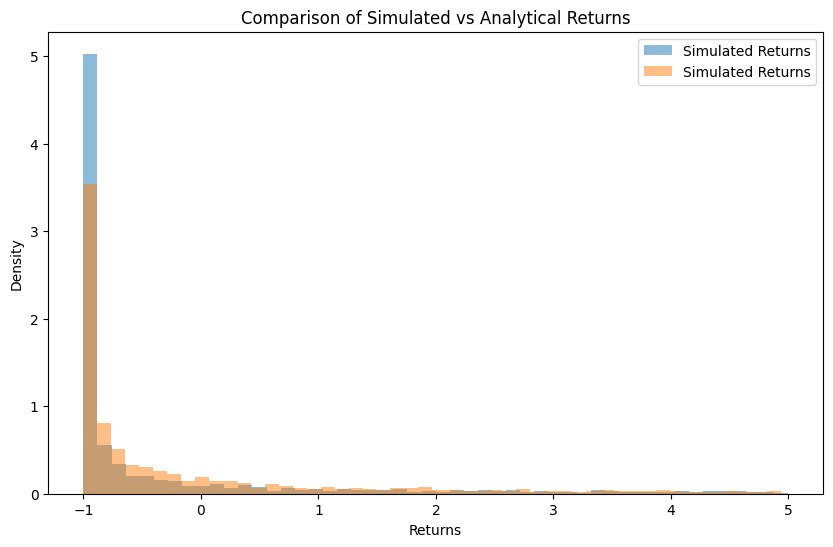

Number of outliers:  (1951,)


In [ ]:
sample_t = stats.t.rvs(size=5000, df=3)
portfolio_t = ProtoPortfolio(sample_t)
portfolio_t.calibrate(horizon=1)
parameters_sim = SimParams(portfolio_t.parameters.volatility, portfolio_t.parameters.mean)

print(portfolio_t.parameters.volatility)

simulator_t = make_random_path_simulator(params=parameters_sim,
                                         T=4,
                                         granularity=1000,
                                         df=3)
simulator_t_lv = make_random_path_simulator_local_vol(params=parameters_sim,
                                         T=4,
                                         granularity=1000,
                                         df=6)
# returns_t = simulator_t(n_paths=5000)
returns_t = _terminal_returns(simulator_t, n_paths=5000, seed=1)
returns_t_lv = _terminal_returns(simulator_t_lv, n_paths=5000, seed=1)
print(returns_t[returns_t > 0].shape)

#simulated returns. Student(1) innovation
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(returns_t[returns_t < 5], bins=50, density=True, alpha=0.5, label='Simulated Returns')
ax.hist(returns_t_lv[returns_t_lv < 5], bins=50, density=True, alpha=0.5, label='Simulated Returns (local volatility)')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.set_title('Comparison of Simulated vs Analytical Returns')
ax.legend()


plt.show()

print('Number of outliers: ',returns_t[returns_t > 5].shape)

0.3244611576792776
(0,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(3,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(56,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(157,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(271,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(380,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(487,)
Number of simulated days exceed number of forecasted volality points. Simulation will assume constant long-term volatility.
(555,)
Number of simulated days exceed number of forecasted volality 

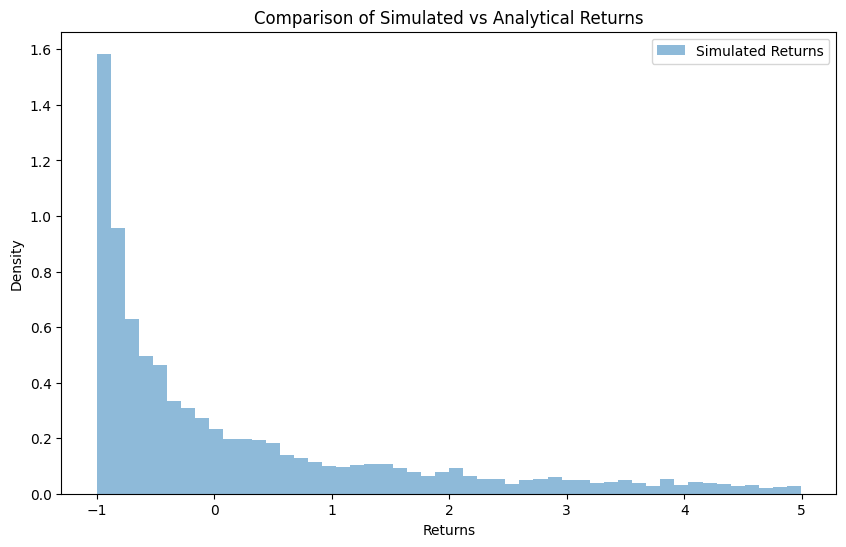

Number of outliers:  (978,)


In [12]:
sample_t = stats.t.rvs(size=5000, df=3, scale=0.2)
print(np.std(sample_t))
portfolio_t = ProtoPortfolio(sample_t)
portfolio_t.calibrate(horizon=1)
parameters_sim = SimParams(portfolio_t.parameters.volatility, portfolio_t.parameters.mean)

n_days = np.linspace(1, 15, 15, dtype=int)
for T in n_days:
    simulator_t = make_random_path_simulator_local_vol(params=parameters_sim,
                                            T=T,
                                            granularity=1000,
                                            df=3)
    # returns_t = simulator_t(n_paths=5000)
    returns_t = _terminal_returns(simulator_t, n_paths=5000)
    print(returns_t[returns_t > 5].shape)

#simulated returns. Student(1) innovation
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms of the terminal returns distribution for 15 days forecasr
ax.hist(returns_t[returns_t < 5], bins=50, density=True, alpha=0.5, label='Simulated Returns')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.set_title('Comparison of Simulated vs Analytical Returns')
ax.legend()


plt.show()

print('Number of outliers: ',returns_t[returns_t > 5].shape)

Real Data tests 

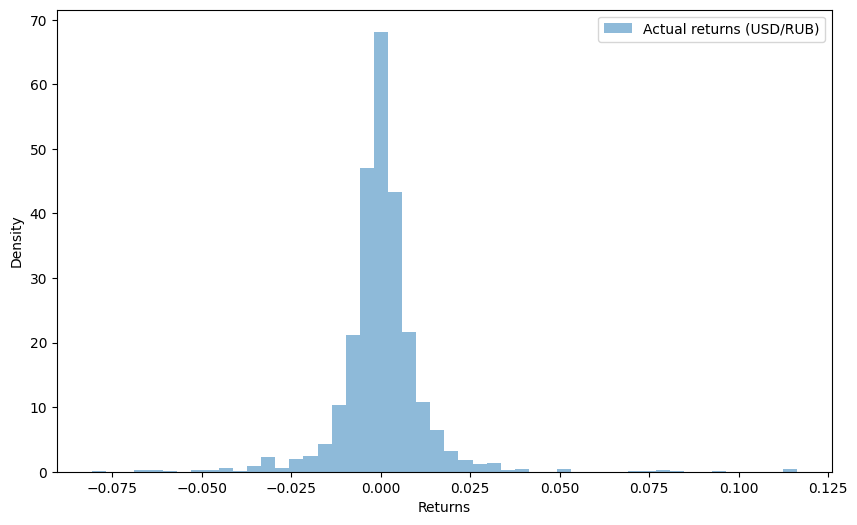

In [225]:
_ = pd.read_excel('hist.xlsx').to_numpy()
prices_usd = _[:, -2]

def return_array(prices): 
    rets = np.diff(prices) / prices[:-1]
    rets = np.array(rets, dtype='float64')
    return rets 

returns_usd  = return_array(prices_usd)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms of the terminal returns distribution for 15 days forecasr
ax.hist(returns_usd, bins=50, density=True, alpha=0.5, label='Actual returns (USD/RUB)')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.legend()

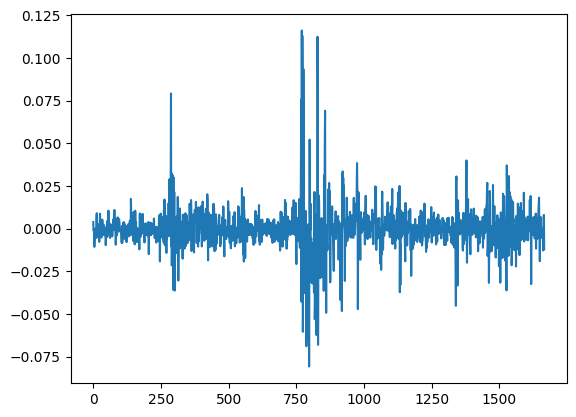

In [218]:
plt.plot(returns_usd)

In [170]:
sample = stats.t.rvs(size=50000, df=3, scale=0.002)
print(np.std(sample))



0.003526741069093554
0.5773502691896258


In [171]:
p_usd = ProtoPortfolio(returns_usd) 
p_usd.calibrate()
params_usd = SimParams(p_usd.parameters.volatility, p_usd.parameters.mean)

simulator_usd_norm = make_random_path_simulator(params_usd, 10, dist='norm')
returns_usd_sim_norm = _terminal_returns(simulator_usd_norm, 50000)
simulator_usd_t = make_random_path_simulator(params_usd, 10, df=3, scale=0.55)
returns_usd_sim_t = _terminal_returns(simulator_usd_t, 50000)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001624. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


C:\Users\alexa\AppData\Local\Temp\ipykernel_38468\2604741422.py:26: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


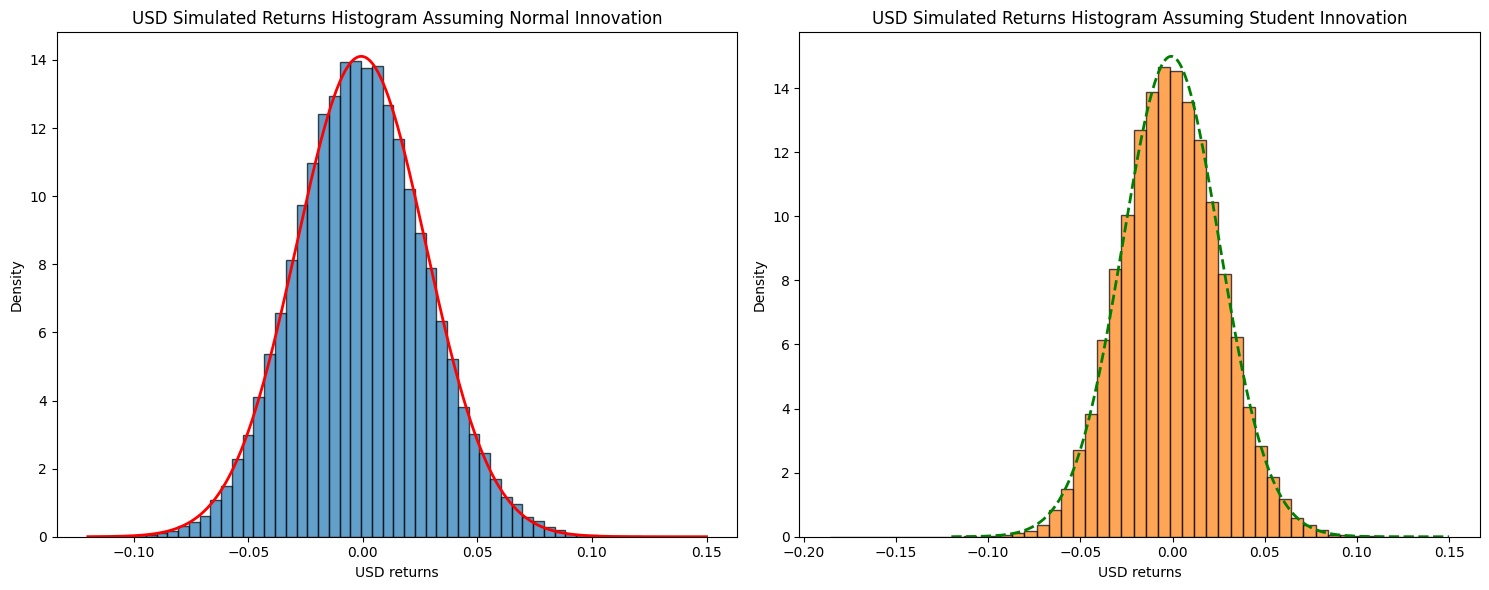

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

# First histogram and normal curve
axes[0].hist(returns_usd_sim_norm, bins=50, color='tab:blue', edgecolor='k', alpha=0.7, density=True)

# Fit normal distribution
mu, sigma = stats.norm.fit(returns_usd_sim_norm)

# Create x values and plot normal pdf
x = np.linspace(-0.12, 0.15, 1000)
axes[0].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
axes[0].set_title('USD Simulated Returns Histogram Assuming Normal Innovation')
axes[0].set_xlabel('USD returns')
axes[0].set_ylabel('Density')

# Second histogram for Student's t-distribution returns
axes[1].hist(returns_usd_sim_t, bins=50, color='tab:orange', edgecolor='k', alpha=0.7, density=True)

# Fit student distribution
df2, loc2, scale2 = stats.t.fit(returns_usd_sim_t)
axes[1].plot(x, stats.t.pdf(x, df2, loc2, scale2), 'g--', linewidth=2, label="t PDF")
axes[1].set_title('USD Simulated Returns Histogram Assuming Student Innovation')
axes[1].set_xlabel('USD returns')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()
plt.show()

In [182]:
Vares.ENABLE_TIMING = False
print(Vares.historical_var(returns_usd_sim_norm, alpha=0.001), Vares.historical_var(returns_usd_sim_t, alpha=0.001))

0.08552545892661124 0.08362310179599872


In [201]:
# Fit a GARCH(1,1) model with Student's t innovations
model = arch_model(returns_usd, vol='GARCH', p=1, q=1, dist='StudentsT')
results = model.fit(disp="off")
mu, omega, alpha, beta, nu = results.params
variance_forecast = results.forecast(horizon=1)
forecasted_variance = variance_forecast.variance[-1:].values.item()
forecasted_std = np.sqrt(forecasted_variance)

params_usd_t = SimParams(mean=mu, volatility=forecasted_std)

simulator_usd_t_2 = make_random_path_simulator(params_usd_t, 10, df=nu)
returns_usd_sim_t_2 = _terminal_returns(simulator_usd_t, 50000)

d:\Users\alexa\AppData\Local\Programs\Python\Python312\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0001624. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(


0.2801469190571602


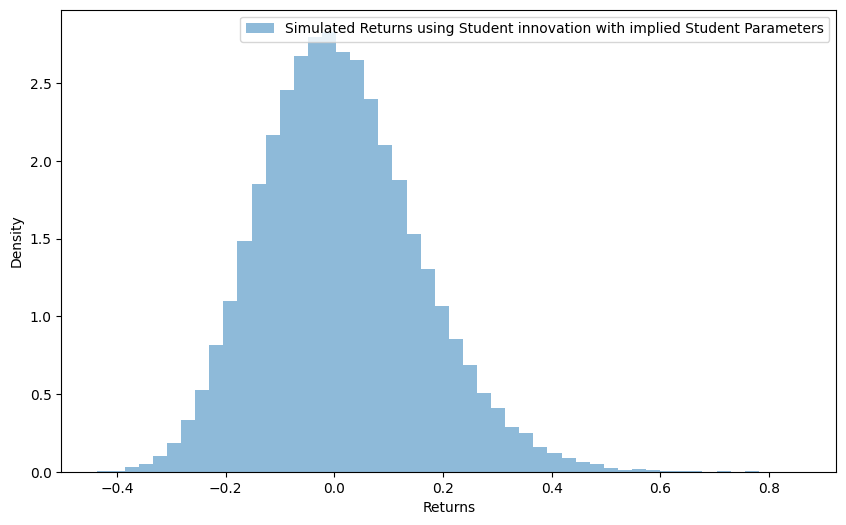

In [207]:
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms of the terminal returns distribution for 15 days forecasr
ax.hist(returns_usd_sim_t_2, bins=50, density=True, alpha=0.5, label='Simulated Returns using Student innovation with implied Student Parameters')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.legend()

print(Vares.historical_var(returns_usd_sim_t_2, alpha=0.01))

ARIMA

In [227]:
import statsmodels as sm 
from statsmodels.tsa.arima.model import ARIMA

#try fitting simple AR(1)
model_ar_1 = ARIMA(returns_usd, order=(1, 0 , 0))
res_ar_1 = model_ar_1.fit()
print(res_ar_1.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1666
Model:                 ARIMA(1, 0, 0)   Log Likelihood                4926.118
Date:                Mon, 27 Oct 2025   AIC                          -9846.236
Time:                        15:00:07   BIC                          -9829.981
Sample:                             0   HQIC                         -9840.212
                               - 1666                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.540      0.589      -0.001       0.001
ar.L1          0.1612      0.009     17.882      0.000       0.143       0.179
sigma2         0.0002   1.69e-06     93.453      0.0

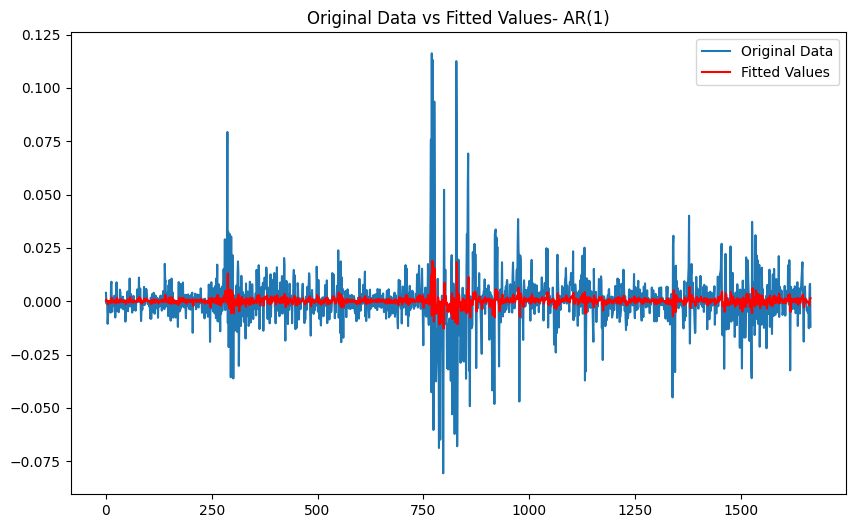

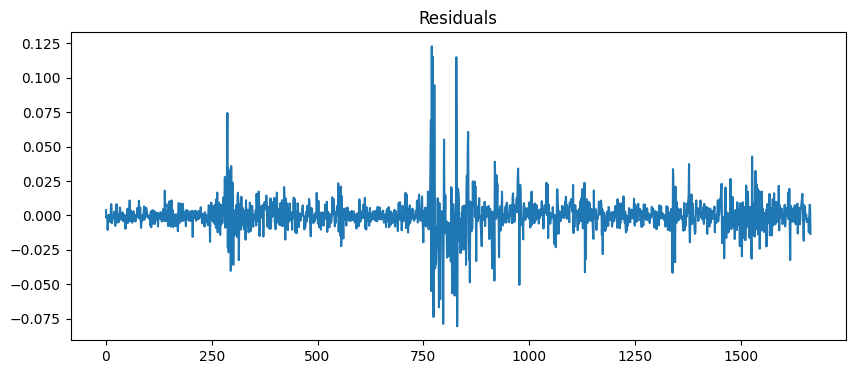

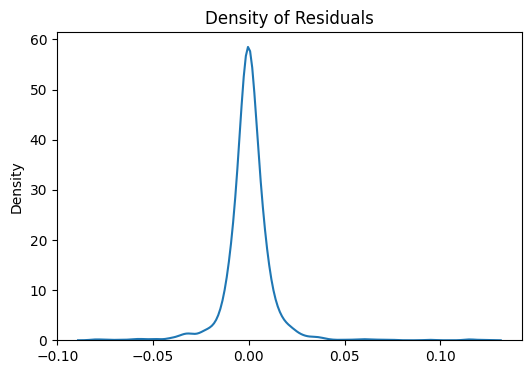

In [234]:
# Plot original data and fitted values
plt.figure(figsize=(10, 6))
plt.plot(model_ar_1.data.endog, label='Original Data')
plt.plot(res_ar_1.fittedvalues, color='red', label='Fitted Values')
plt.title('Original Data vs Fitted Values- AR(1)')
plt.legend()
plt.show()

# Plot residuals to check for randomness (model errors)
residuals = res_ar_1.resid
plt.figure(figsize=(10, 4))
plt.plot(residuals)
plt.title('Residuals')
plt.show()

# Plot residuals distribution to check normality assumption
plt.figure(figsize=(6, 4))
sns.kdeplot(res_ar_1.resid)
plt.title('Density of Residuals')
plt.show()

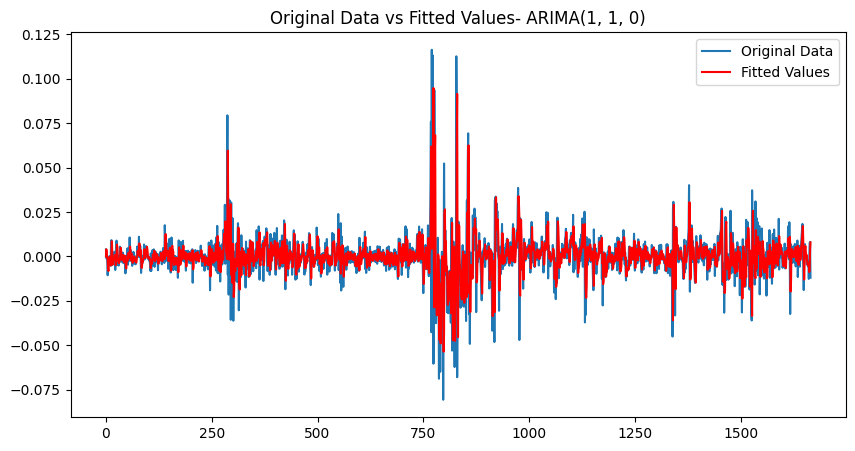

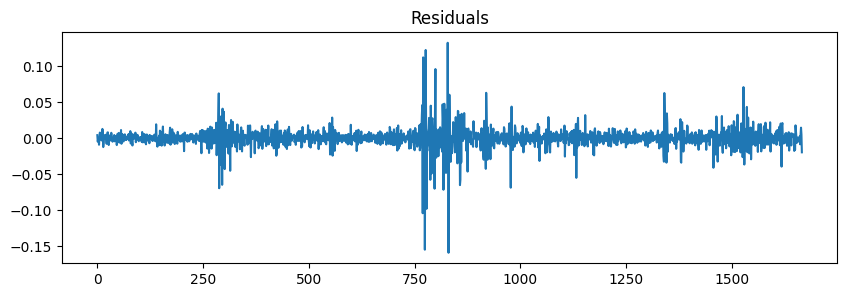

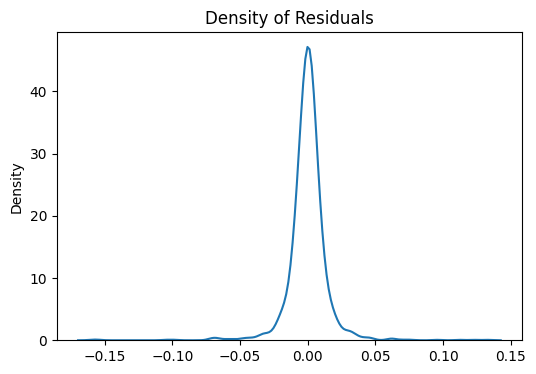

In [256]:
# p, q, d = 1, 1, 0
p, q, d = 1, 1, 0

model_ = ARIMA(returns_usd, order=(p, q , d))
res = model_.fit()

# Plot original data and fitted values
plt.figure(figsize=(10, 5))
plt.plot(model_.data.endog, label='Original Data')
plt.plot(res.fittedvalues, color='red', label='Fitted Values')
plt.title(f'Original Data vs Fitted Values- ARIMA({p}, {q}, {d})')
plt.legend()
plt.show()

# Plot residuals to check for randomness (model errors)
residuals = res.resid
plt.figure(figsize=(10, 3))
plt.plot(residuals)
plt.title('Residuals')
plt.show()

# Plot residuals distribution to check normality assumption
plt.figure(figsize=(6, 4))
sns.kdeplot(res.resid)
plt.title('Density of Residuals')
plt.show()

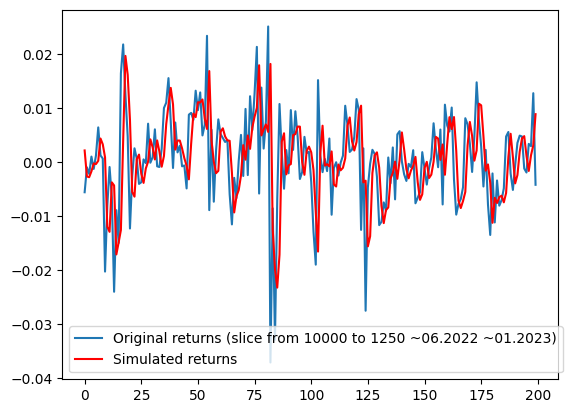

In [257]:
returns_ar_1 = res.fittedvalues
stable_slice_sim = returns_ar_1[1050:1250]
stable_slice = returns_usd[1050:1250]
plt.plot(stable_slice, label='Original returns (slice from 10000 to 1250 ~06.2022 ~01.2023)')
plt.plot(stable_slice_sim, color='red', label='Simulated returns')
plt.legend()
plt.show()
plt.show()

ARMA(1, 1) MSE: 0.00022966336559698445, ARMA(2, 2) MSE: 0.0003759616321128936


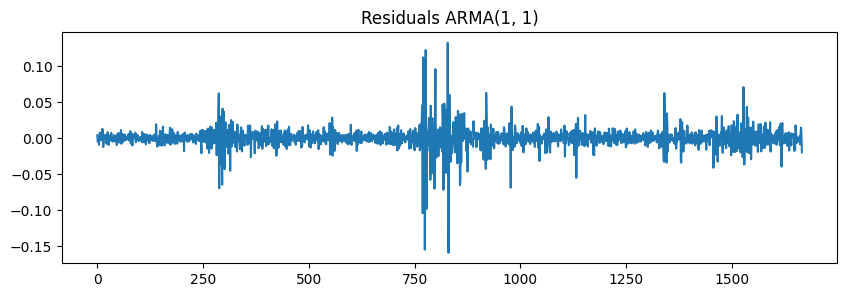

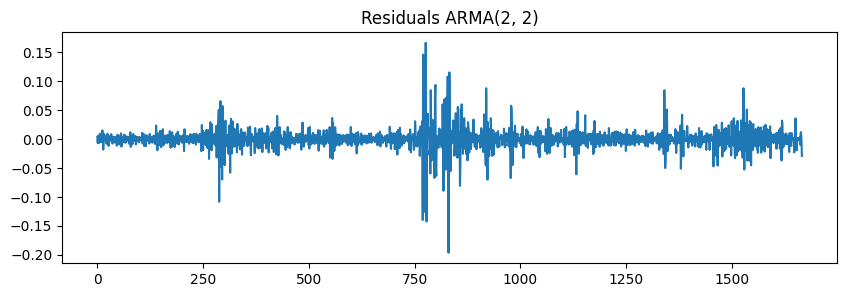

In [273]:
#residuals sum ARMA(1, 1) vs ARMA(2, 2)
p1, q1, d1 = 1, 1, 0
p2, q2, d2 = 2, 2, 0

m1 = ARIMA(returns_usd, order=(p1, q1, d1))
res1 = m1.fit()

m2 = ARIMA(returns_usd, order=(p2, q2, d2))
res2 = m2.fit()

resid1 = res1.resid
resid2 = res2.resid

print(f'ARMA(1, 1) MSE: {res1.mse}, ARMA(2, 2) MSE: {res2.mse}')

plt.figure(figsize=(10, 3))
plt.plot(resid1)
plt.title('Residuals ARMA(1, 1)')
plt.show()

plt.figure(figsize=(10, 3))
plt.plot(resid2)
plt.title('Residuals ARMA(2, 2)')
plt.show()


ARMA(1,1) MAE: 0.008569475643725406
ARMA(1,1) MSE: 0.00022966336559698445
ARMA(1,1) AIC: -9220.710939864013
ARMA(1,1) BIC: -9209.875779059184
ARMA(1,1) Log-Likelihood: 4612.355469932007
ARMA(2,2) MAE: 0.0111796442824922
ARMA(2,2) MSE: 0.0003759616321128936
ARMA(2,2) AIC: -8391.35133301175
ARMA(2,2) BIC: -8375.100394147606
ARMA(2,2) Log-Likelihood: 4198.675666505875


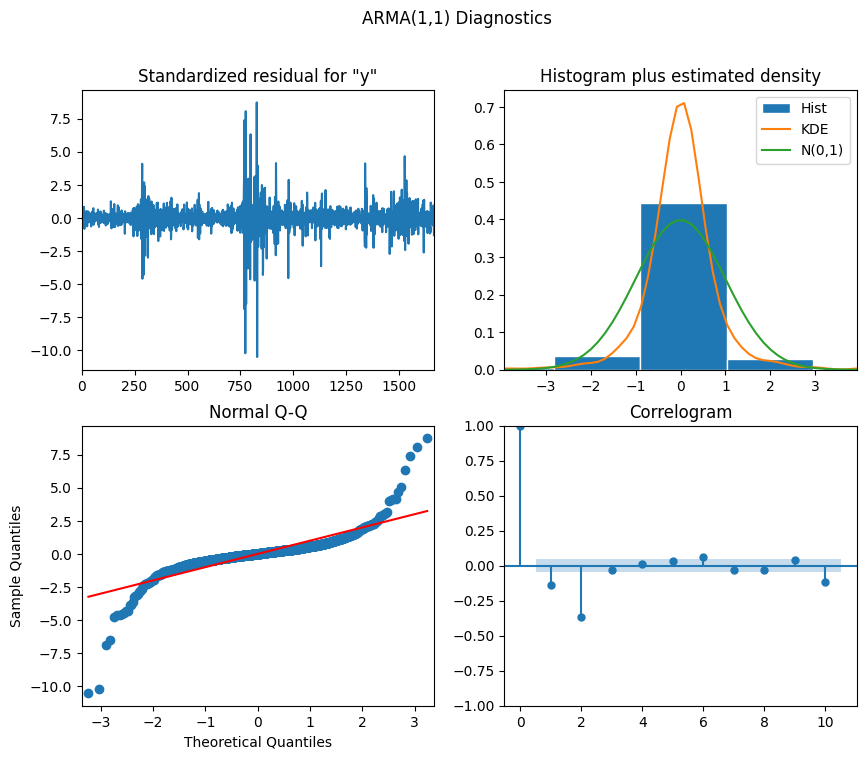

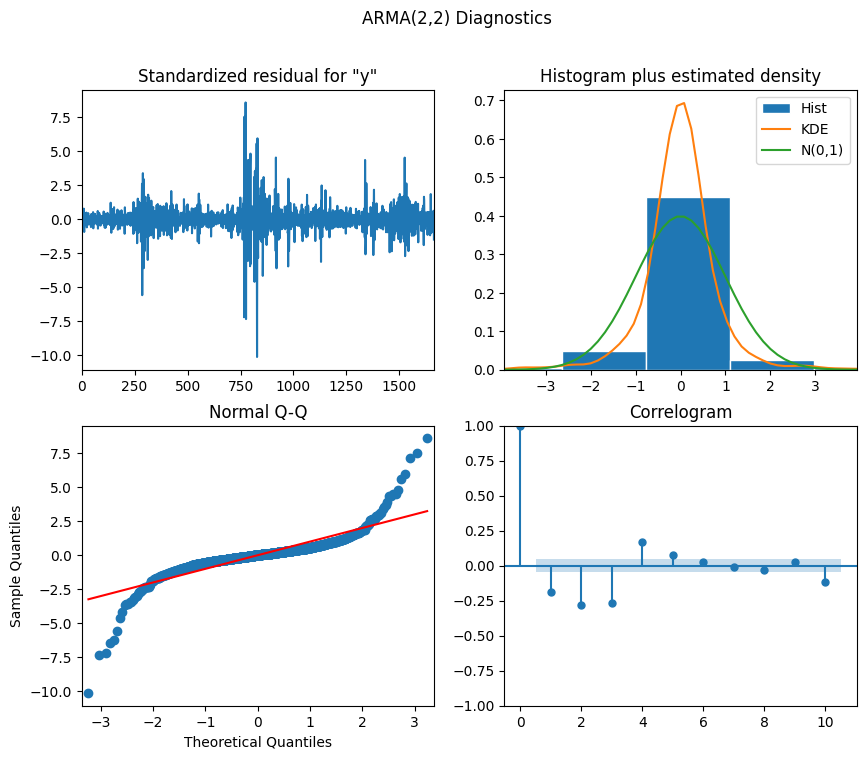

In [277]:
print("ARMA(1,1) MAE:", res1.mae)
print("ARMA(1,1) MSE:", res1.mse)
print("ARMA(1,1) AIC:", res1.aic)
print("ARMA(1,1) BIC:", res1.bic)
print("ARMA(1,1) Log-Likelihood:", res1.llf)

print("ARMA(2,2) MAE:", res2.mae)
print("ARMA(2,2) MSE:", res2.mse)
print("ARMA(2,2) AIC:", res2.aic)
print("ARMA(2,2) BIC:", res2.bic)
print("ARMA(2,2) Log-Likelihood:", res2.llf)

res1.plot_diagnostics(figsize=(10,8))
plt.suptitle('ARMA(1,1) Diagnostics')
plt.show()

res2.plot_diagnostics(figsize=(10,8))
plt.suptitle('ARMA(2,2) Diagnostics')
plt.show()

In [290]:
def mse(array1 , array2):
    return np.mean((array1 - array2)**2)

def mae(array1 , array2):
    return np.mean(np.abs(array1 - array2))

f1 = res1.fittedvalues
mse1 = mse(f1, returns_usd)

f2 = res2.fittedvalues
mse2 = mse(f2, returns_usd)

print(mse1, mse2)

print(np.mean(np.abs(returns_usd)))
print(mae(returns_usd, 0))

0.00022966336559698445 0.0003759616321128936
0.0072536240130426895
0.0072536240130426895


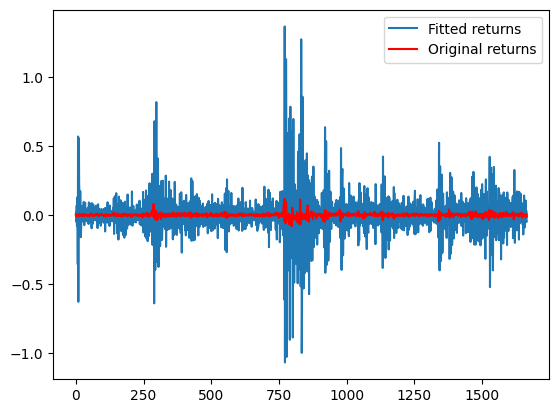

In [296]:
model10 = ARIMA(returns_usd, order=(10, 10, 0))
res10 = model10.fit()
ress = res10.fittedvalues
plt.plot(ress, label='Fitted returns')
plt.plot(returns_usd, color='red', label='Original returns')
plt.legend()
plt.show()

Graphs


99% quantile for simulated returns: 0.5585
99% quantile for analytical returns: 0.5532


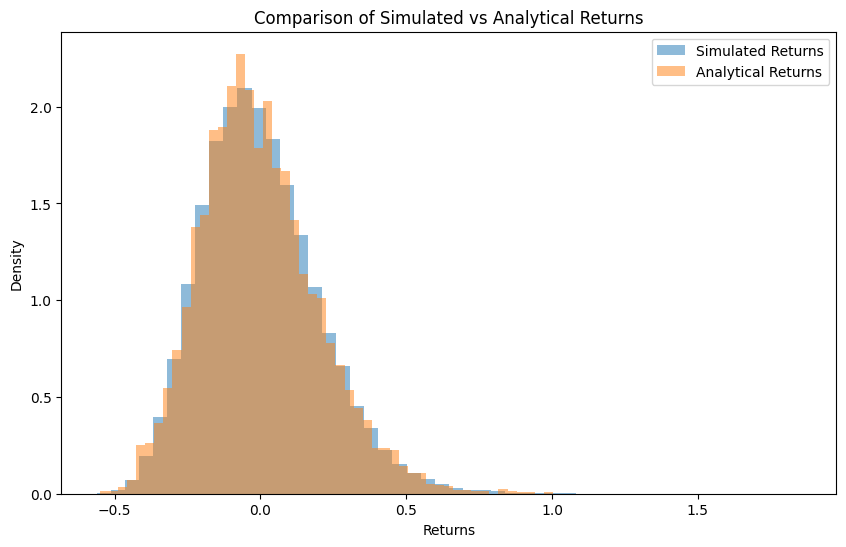

In [85]:
#simulated vs analytical returns for simple GBM
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(returns_simulation, bins=50, density=True, alpha=0.5, label='Simulated Returns')
ax.hist(returns_analytical, bins=50, density=True, alpha=0.5, label='Analytical Returns')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.set_title('Comparison of Simulated vs Analytical Returns')
ax.legend()

# Calculate and display 99% quantiles
q_sim = np.quantile(returns_simulation, 0.99)
q_ana = np.quantile(returns_analytical, 0.99)

print(f'99% quantile for simulated returns: {q_sim:.4f}')
print(f'99% quantile for analytical returns: {q_ana:.4f}')

plt.show()

99% quantile for simulated returns: 1.3872
99% quantile for analytical returns: 1.3240


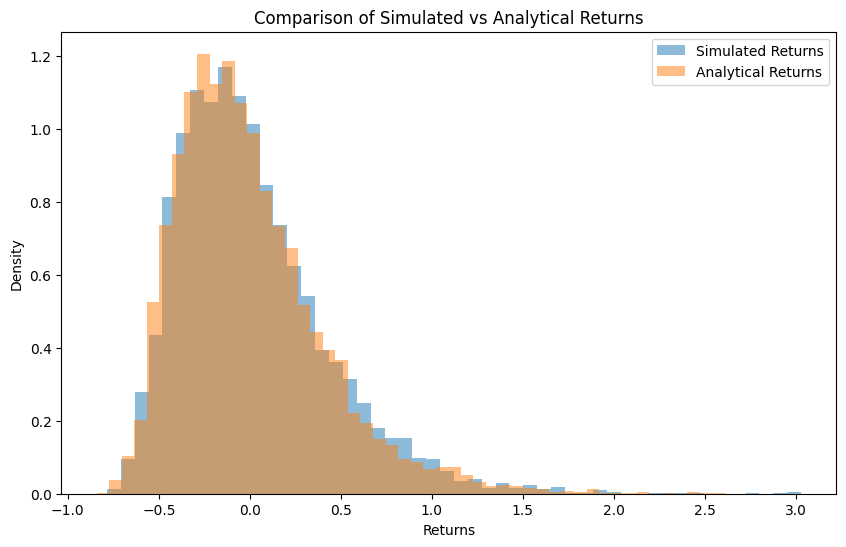

In [91]:
#simulated vs analytical returns for local volatility GBM
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(returns_local_vol_sim, bins=50, density=True, alpha=0.5, label='Simulated Returns')
ax.hist(returns_local_vol_ana, bins=50, density=True, alpha=0.5, label='Analytical Returns')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.set_title('Comparison of Simulated vs Analytical Returns (Local Volality)')
ax.legend()

# Calculate and display 99% quantiles
q_sim = np.quantile(returns_local_vol_sim, 0.99)
q_ana = np.quantile(returns_local_vol_ana, 0.99)

print(f'99% quantile for simulated returns: {q_sim:.4f}')
print(f'99% quantile for analytical returns: {q_ana:.4f}')

plt.show()

In [ ]:
#convergence of the simulation of the simple GBM to theoretical value
Vares.ENABLE_TIMING = False

# lognormal quantile at alpha=0.01 for underlying normal(mean=0, std=0.2)
alpha = 0.01
mu = - ((0.2**2)/2)
sigma = 0.2

# SciPy lognorm parameterization: s = sigma, scale = exp(mu)
value_at_alpha = stats.lognorm.ppf(alpha, s=sigma, scale=np.exp(mu), loc=-1)
var_theoretical = - value_at_alpha

number_of_simulations = np.linspace(10, 5000, 500, dtype=int)

vars_simulated = []
params = GBMParams(mean=0, volatility=0.2)
sim = make_gbm_simulator(params, 1)

for n_paths in number_of_simulations: 
    r = _terminal_returns(sim, n_paths)
    vars_simulated.append(Vares.historical_var(r, alpha))


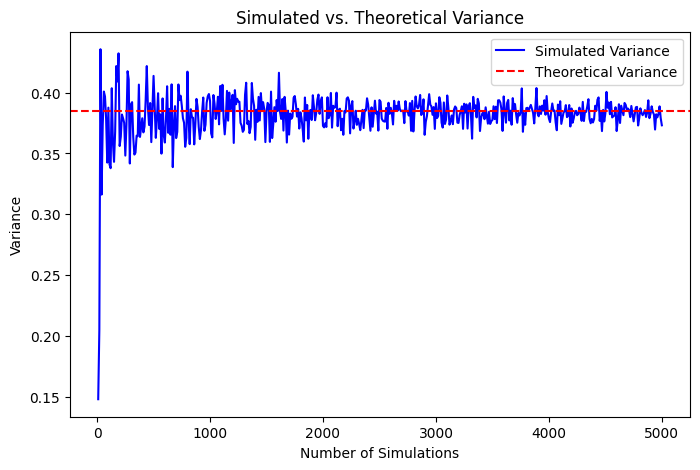

In [105]:
plt.figure(figsize=(8, 5))
plt.plot(number_of_simulations, vars_simulated, color='blue', label='Simulated Variance')
plt.axhline(y=var_theoretical, color='red', linestyle='--', label='Theoretical Variance')
plt.xlabel('Number of Simulations')
plt.ylabel('Variance')
plt.title('Simulated vs. Theoretical Variance')
plt.legend()
# plt.grid(True)
plt.show()

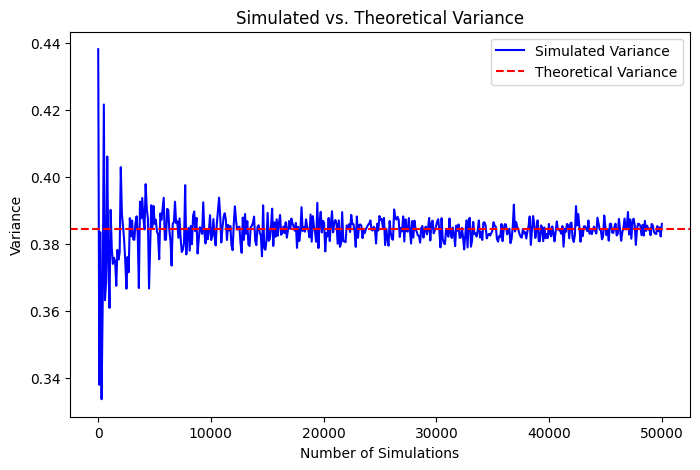

In [106]:
#convergence of the simulation of the simple GBM to theoretical value
Vares.ENABLE_TIMING = False

# lognormal quantile at alpha=0.01 for underlying normal(mean=0, std=0.2)
alpha = 0.01
mu = - ((0.2**2)/2)
sigma = 0.2

# SciPy lognorm parameterization: s = sigma, scale = exp(mu)
value_at_alpha = stats.lognorm.ppf(alpha, s=sigma, scale=np.exp(mu), loc=-1)
var_theoretical = - value_at_alpha

number_of_simulations = np.linspace(10, 50000, 500, dtype=int)

vars_simulated = []
params = GBMParams(mean=0, volatility=0.2)
sim = make_gbm_simulator(params, 1)

for n_paths in number_of_simulations: 
    r = _terminal_returns(sim, n_paths)
    vars_simulated.append(Vares.historical_var(r, alpha))

plt.figure(figsize=(8, 5))
plt.plot(number_of_simulations, vars_simulated, color='blue', label='Simulated Variance')
plt.axhline(y=var_theoretical, color='red', linestyle='--', label='Theoretical Variance')
plt.xlabel('Number of Simulations')
plt.ylabel('Variance')
plt.title('Simulated vs. Theoretical Variance')
plt.legend()
# plt.grid(True)
plt.show()

[ 4.87042675 -0.87997528 -0.92681956 ... -0.99019956 -0.96265862
 -0.02627743] [1.64496475]


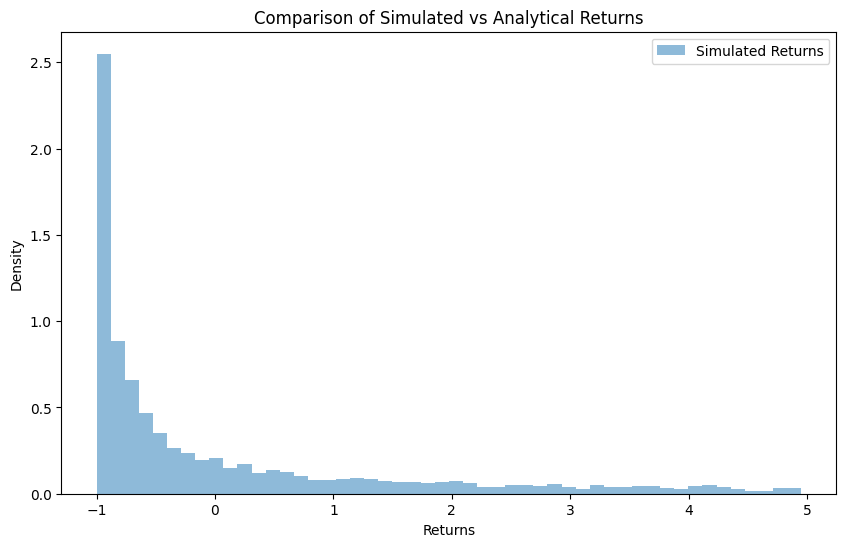

Number of outliers:  (1324,)


In [45]:
sample_t = stats.t.rvs(size=5000, df=3)
portfolio_t = ProtoPortfolio(sample_t)
portfolio_t.calibrate()
parameters_sim = SimParams(portfolio_t.parameters.volatility, portfolio_t.parameters.mean)
simulator_t = make_random_path_simulator(params=parameters_sim,
                                         T=1,
                                         granularity=1000,
                                         df=3)
# returns_t = simulator_t(n_paths=5000)
returns_t = _terminal_returns(simulator_t, n_paths=5000)
print(returns_t, parameters_sim.volatility)

#simulated returns. Student(1) innovation
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histograms
ax.hist(returns_t[returns_t < 5], bins=50, density=True, alpha=0.5, label='Simulated Returns')
# ax.hist(sample_t, bins=50, density=True, alpha=0.5, label='Simulated Returns')

# Add labels and title
ax.set_xlabel('Returns')
ax.set_ylabel('Density')
ax.set_title('Comparison of Simulated vs Analytical Returns')
ax.legend()


plt.show()

print('Number of outliers: ',returns_t[returns_t > 5].shape)